# NEW SYSTEM

### Naming convention
|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|TransitionType|constant attributes of photophysical transition|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|emission|fluorescent emission|
|event|detected fluorescent emission|
|resample|frame integration time|

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc
import src.formulas as fo
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

C:\Users\SagixOffice\miniconda3\envs\markovmodels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


### Setup the fluorophores

In [2]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=10, count=3, shape='square', parameter_set='set 1')
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

array([[<AxesSubplot:xlabel='x [nm]', ylabel='y [nm]'>]], dtype=object)

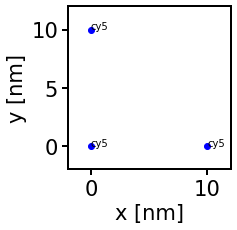

In [3]:
fluorophore_system.plot()

### Setup the transitions

In [12]:
transitions = fluorophore_system.load_transitions(2.5, 640, bleaching=False)

In [13]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [31]:
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'CFRET', 'OFRET', 'STA'])

In [32]:
transition_set = transition_set.adjust_rates({'BLE1': 1e6})

In [33]:
transition_set.finalize()

In [34]:
transition_set.transition_df

,transition_type,abbreviation,initial_state,final_state,rate,photon,energy_transfer,distance
id,,,,,,,,
0,TransitionType.EXCITATION,EXC,SingleState.S0,SingleState.S1,7.269626e+06,False,False,None
1,TransitionType.FLUORESCENT_EMISSION,FLU,SingleState.S1,SingleState.S0,2.700000e+08,True,False,None
2,TransitionType.INTERSYSTEM_CROSSING_ST,ISCST,SingleState.S1,SingleState.T1,8.300000e+05,False,False,None
3,TransitionType.INTERSYSTEM_CROSSING_TS,ISCTS,SingleState.T1,SingleState.S0,5.000000e+05,False,False,None
4,TransitionType.ISOMERIZATION,ISO,SingleState.S1,SingleState.Cis,2.000000e+07,False,False,None
5,TransitionType.BACKISOMERIZATION,BISO,SingleState.Cis,SingleState.S0,1.369280e+05,False,False,None
6,TransitionType.INTERNAL_CONVERSION_S,ICS,SingleState.S1,SingleState.S0,7.091700e+08,False,False,None
7,TransitionType.REDUCTION_T,REDT,SingleState.T1,SingleState.OFF,4.383440e+02,False,False,None
8,TransitionType.OXIDATION,OXI,SingleState.OFF,SingleState.S0,2.000000e-02,False,False,None


<AxesSubplot:>

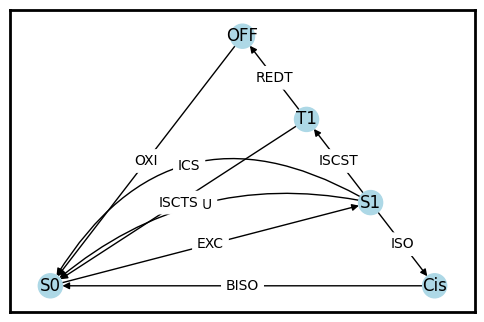

In [35]:
transition_set.plot(graph_type='planar')

### Prediction

In [25]:
prediction = st.Prediction(transition_set)

array([[<AxesSubplot:title={'center':'occurrences'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'lifetimes'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>,
        <AxesSubplot:title={'center':'occupation'}, ylabel='PR'>],
       [<AxesSubplot:title={'center':'transitions'}, ylabel='PR'>,
        <AxesSubplot:title={'center':'time to transition'}, ylabel='mean [s]'>,
        <AxesSubplot:xlabel='time to transition [s]', ylabel='PD'>,
        <AxesSubplot:>]], dtype=object)

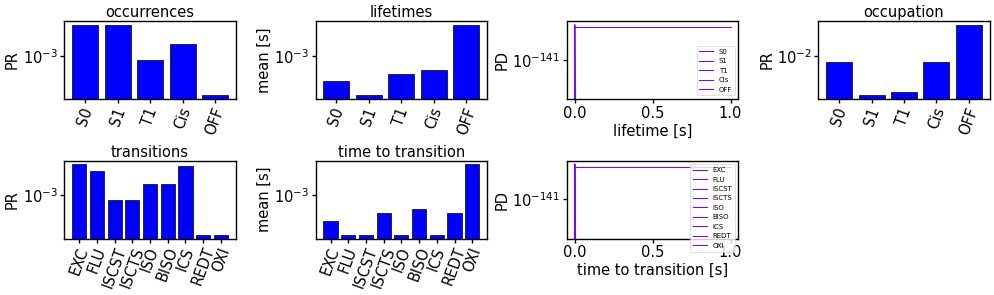

In [26]:
prediction.plot_all()

### Simulation

In [9]:
simulation = si.Simulation(transition_set)

In [36]:
simulation.run(size=int(1e7), end_time=None, seed=3, use_memmap=None)

### Analysis

### Note to energy transfers:
- only has an impact on the true fluorescence lifetime if acceptors are truly available
    - e.g., if the potential acceptor fluorophore is in long living triplet state, homoFRET is not available and the true fluorescence lifetime does not include the rate of homoFRET
    - if multiple fluorophores in certain distances are available as acceptor, the true fluorescence lifetime takes all of their respective rates into account
    - depending on the number of fluorophores and possible longliving non-accepting states, the impact of energy transfers such as homoFRET may have only a marginal impact on the mean true fluorescence lifetime
- the analysis follows the following rules:
    - time to transitions of energy transfers are collected only from the donor's point of view
    - time to transition of e.g., fluorescence, does not differentiate whether energy transfer was also an option or not
    - one occurrence resembles the transition of the donor and the acceptor
    - state lifetimes and occurrences do not differentiate whether energy transfer was involved or not

In [31]:
analysis = st.Analysis(simulation)

TypeError: object of type 'numpy.float64' has no len()

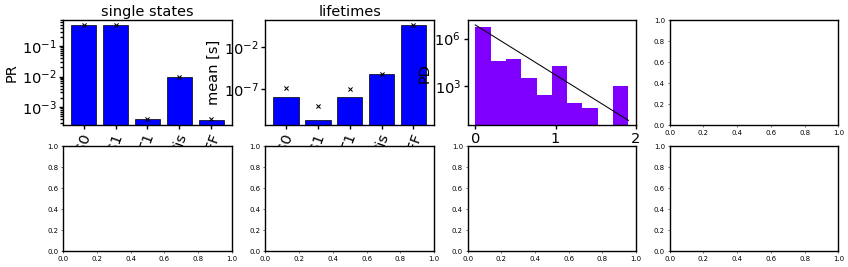

In [32]:
analysis.plot_all(prediction=prediction)

### Emissions

In [33]:
emissions = em.Emissions(simulation, photon_collection_rate=1, resample='4ms', emccd_gain=10, seed=100)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

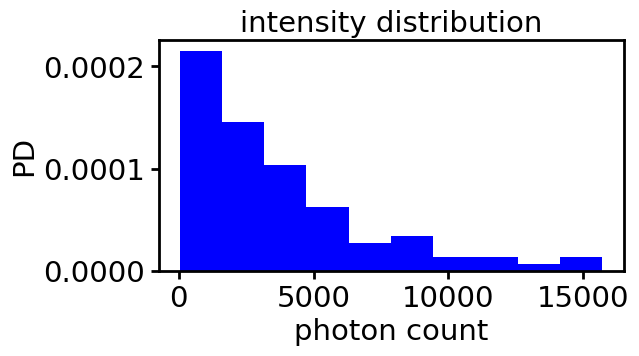

In [34]:
emissions.plot(mode='histogram')

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

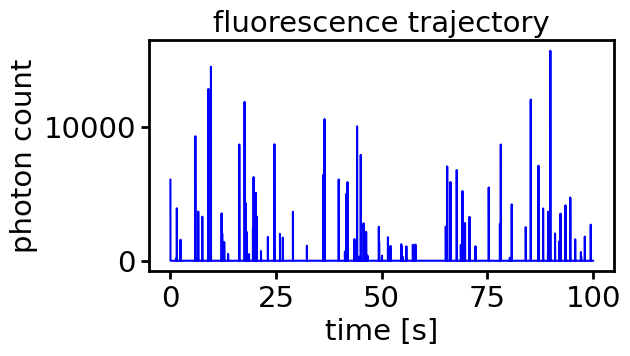

In [35]:
emissions.plot(mode='time_series')

### fcs

In [36]:
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-10, exp_max=-1)

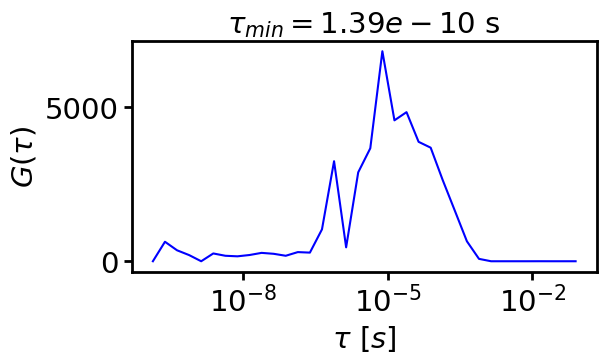

In [37]:
ax = fcs.plot()

### blinking

#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.

In [21]:
blinking = bl.Blinking(emissions)

array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

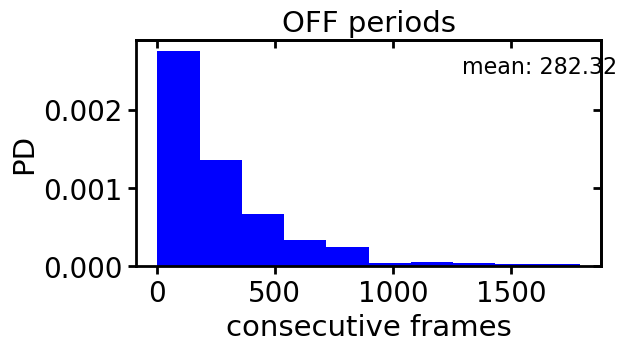

In [22]:
blinking.plot(mode='off_histogram')

### tcspc

In [16]:
tcspc = tc.TCSPC(transition_set)

In [17]:
tcspc.run(size=100000, seed=100)

In [18]:
tcspc.get_observed_lifetimes()

array([[<AxesSubplot:title={'center':'simulation'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

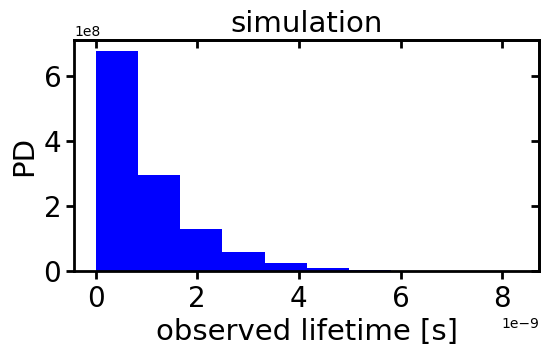

In [19]:
tcspc.plot()

In [20]:
tcspc.predict(accuracy=10, size=1000)

array([[<AxesSubplot:title={'center':'prediction'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

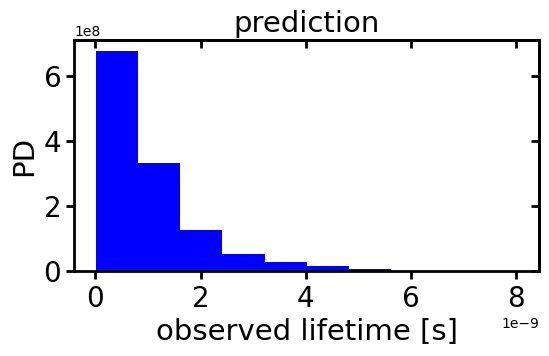

In [21]:
tcspc.plot('prediction')